<>:37: SyntaxWarning: invalid escape sequence '\c'
<>:37: SyntaxWarning: invalid escape sequence '\c'
/var/folders/sh/ysn0s_2j5b34_xvss81l78c80000gn/T/ipykernel_49005/1174724966.py:37: SyntaxWarning: invalid escape sequence '\c'
  QPT.plot_matrix(fit["chi"], Pauli_labels, title_prefix = "$\chi$ $matrix$",save_name = Folder_name + "/figure_" + Data_file_name)


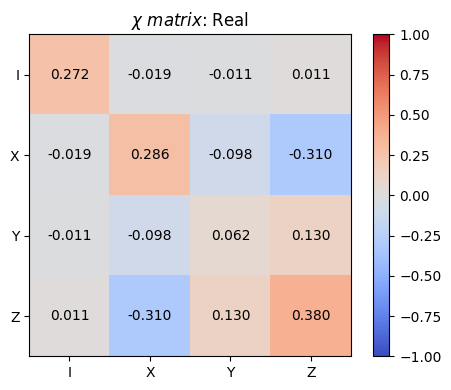

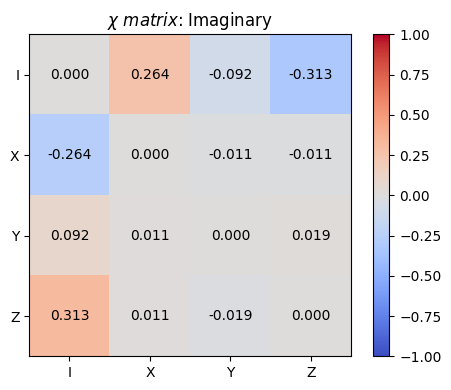

In [1]:
from Quantum_EAPT_CPTP import Quantum_EAPT_CPTP
import os

QPT = Quantum_EAPT_CPTP

Data_file_name_raw = "QWPCW14deg_HWPCCW12deg_20260507"
Source_state = "Psi+"
Data_file_name = Data_file_name_raw + "_labeled"
csv_path = Data_file_name + ".csv"
QPT.header_from_raw(Data_file_name_raw + ".csv", csv_path)
Folder_name = Data_file_name + "_QPT_analysis_CPTP_rotate_20260713"
os.makedirs(Folder_name, exist_ok=True)
Coincidence_data = QPT.load_labeled_coincidence_csv(

    csv_path,

    reference_col="Idler",

    channel_col="Signal",

    count_col="count",

    output_matrix_csv=Folder_name + "/" + Data_file_name + "_matrix_labeled.csv",

)

fit = QPT.qpt_mle_chi_from_psi_plus_coincidences(

    Coincidence_data,

    bell_state_name = Source_state,

)

Pauli, Stokes, Pauli_labels, Stokes_labels = QPT.pauli_stokes_basis()

QPT.plot_matrix(fit["chi"], Pauli_labels, title_prefix = "$\chi$ $matrix$",save_name = Folder_name + "/figure_" + Data_file_name)

QPT.save_fit_return_values_as_csv_tables(

    fit,

    folder = Folder_name,

    prefix = Data_file_name_raw,

)

In [ ]:
from Quantum_EAPT_NTP import Quantum_EAPT_NTP
import os
import numpy as np
import pandas as pd
from pathlib import Path
QPT = Quantum_EAPT_NTP

In [ ]:
Data_file_name_raw = "QWPCW14deg_HWPCCW12deg_20260507"
Source_state = "Psi+"
Data_file_name = Data_file_name_raw + "_labeled"
csv_path = Data_file_name + ".csv"
QPT.header_from_raw(Data_file_name_raw + ".csv", csv_path)
Folder_name = Data_file_name + "_QPT_analysis_NTP_rotate_20260713"
os.makedirs(Folder_name, exist_ok=True)
Coincidence_data = QPT.load_labeled_coincidence_csv(

    csv_path,

    reference_col="Idler",

    channel_col="Signal",

    count_col="count",

    output_matrix_csv=Folder_name + "/" + Data_file_name + "_matrix_labeled.csv",

)

fit = QPT.qpt_mle_chi_from_psi_plus_coincidences_cp_only(

    Coincidence_data,

    bell_state_name = Source_state,

)
Pauli, Stokes, Pauli_labels, Stokes_labels = QPT.pauli_stokes_basis()

QPT.plot_matrix(fit["chi"], Pauli_labels, title_prefix = "$\chi$ $matrix$",save_name = Folder_name + "/figure_" + Data_file_name)

QPT.save_fit_return_values_as_csv_tables(

    fit,

    folder = Folder_name,

    prefix = Data_file_name_raw,

)

In [ ]:
def load_chi_from_csv(real_csv_path, imag_csv_path):

    chi_real = pd.read_csv(real_csv_path, index_col=0).to_numpy(dtype=float)
    chi_imag = pd.read_csv(imag_csv_path, index_col=0).to_numpy(dtype=float)

    chi = chi_real + 1j * chi_imag

    return chi

def chi2mueller(chi, Pauli_basis, Stokes_basis):
    if chi.shape != (4, 4):
        raise ValueError(f"chi must be 4x4, got {chi.shape}")

    M_complex = np.zeros((4, 4), dtype=complex)

    for mu in range(4):
        for nu in range(4):
            value = 0.0 + 0.0j

            for m in range(4):
                for n in range(4):
                    value += (
                        chi[m, n]
                        * np.trace(
                            Stokes_basis[mu]
                            @ Pauli_basis[m]
                            @ Stokes_basis[nu].conj().T
                            @ Pauli_basis[n].conj().T
                        )
                    )

            M_complex[mu, nu] = 0.5 * value
            
    if np.sum(np.imag(M_complex)) > 10e-10:
        raise ValueError("Mueller matrix should be a real matrix")
    M = np.real(M_complex)
    M /= M[0, 0]

    return M

def save_mueller_csv(M, output_csv_path):
    if M.shape != (4, 4):
        raise ValueError(f"Mueller matrix must be 4x4, got {M.shape}")

    np.savetxt(output_csv_path, M, delimiter=",", fmt="%.10g")

In [ ]:
real_csv = Folder_name + "/result/" + Data_file_name_raw + "_chi_real.csv"
imag_csv = Folder_name + "/result/" + Data_file_name_raw + "_chi_imag.csv"
output_name = Folder_name + "/Mueller_" + Data_file_name_raw

Chi = load_chi_from_csv(real_csv, imag_csv)

bb = chi2mueller(Chi, Pauli, Stokes)

QPT.plot_matrix(bb, Stokes_labels, "$Mueller$ $matrix$", output_name)
save_mueller_csv(bb, output_name + ".csv")

Mueller matrix decomposition code

In [ ]:
def load_mueller_csv(csv_path):
    
    csv_path = Path(csv_path)
    
    df = pd.read_csv(csv_path, header=None)
    df_num = df.apply(pd.to_numeric, errors="coerce")

    df_num = df_num.dropna(axis=0, how="all")
    df_num = df_num.dropna(axis=1, how="all")

    arr = df_num.to_numpy(dtype=float)

    M = arr[:4, :4].astype(float)

    return M

def mueller2cov(M, Stokes_basis):
    
    sigmas = Stokes_basis
    H = np.zeros((4, 4), dtype = complex)

    for k in range(4):
        for l in range(4):
            H += M[k, l] * np.kron(sigmas[k], sigmas[l])
    H = H / 4.0

    H = 0.5 * (H + H.conj().T)
    return H

def cov2mueller(H, Stokes_basis):
    
    sigmas = Stokes_basis
    M = np.zeros((4, 4), dtype=float)

    for k in range(4):
        for l in range(4):
            A = np.kron(sigmas[k], sigmas[l])
            M[k, l] = np.real(np.trace(A @ H))

    return M

In [ ]:
MM = load_mueller_csv(output_name + ".csv")

HH = mueller2cov(MM, Stokes)

# print(HH)

MMM = cov2mueller(HH, Stokes)

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path


# ============================================================
# 1. CSV loading
# ============================================================

def load_mueller_csv(csv_path, normalize_m00=False):
    """
    Load a 4x4 real-valued Mueller matrix from CSV.

    Parameters
    ----------
    csv_path : str or Path
        CSV file path.
    normalize_m00 : bool
        If True, divide the matrix by M[0,0].

    Returns
    -------
    M : ndarray, shape (4,4)
        Real Mueller matrix.
    """
    csv_path = Path(csv_path)

    # Header가 있어도 숫자만 골라내기 위해 coercion 사용
    df = pd.read_csv(csv_path, header=None)
    df_num = df.apply(pd.to_numeric, errors="coerce")

    # 완전히 NaN인 row/column 제거
    df_num = df_num.dropna(axis=0, how="all")
    df_num = df_num.dropna(axis=1, how="all")

    arr = df_num.to_numpy(dtype=float)

    if arr.shape[0] < 4 or arr.shape[1] < 4:
        raise ValueError(f"CSV에서 4x4 matrix를 찾을 수 없습니다. 현재 shape = {arr.shape}")

    M = arr[:4, :4].astype(float)

    if normalize_m00:
        if abs(M[0, 0]) < 1e-15:
            raise ValueError("M[0,0]이 0에 가까워 normalize할 수 없습니다.")
        M = M / M[0, 0]

    return M


# ============================================================
# 2. Mueller <-> covariance matrix conversion
#    Paper convention:
#    sigma0 = I
#    sigma1 = [[1,0],[0,-1]]
#    sigma2 = [[0,1],[1,0]]
#    sigma3 = [[0,-i],[i,0]]
# ============================================================

def pauli_stokes_basis():
    sigma0 = np.array([[1, 0], [0, 1]], dtype=complex)
    sigma1 = np.array([[1, 0], [0, -1]], dtype=complex)
    sigma2 = np.array([[0, 1], [1, 0]], dtype=complex)
    sigma3 = np.array([[0, -1j], [1j, 0]], dtype=complex)
    return [sigma0, sigma1, sigma2, sigma3]


def mueller2cov(M):
    """
    H = 1/4 sum_{k,l} M[k,l] sigma_k ⊗ sigma_l

    Parameters
    ----------
    M : ndarray, shape (4,4)

    Returns
    -------
    H : ndarray, shape (4,4), complex Hermitian ideally
    """
    sigmas = pauli_stokes_basis()
    H = np.zeros((4, 4), dtype=complex)

    for k in range(4):
        for l in range(4):
            H += M[k, l] * np.kron(sigmas[k], sigmas[l])

    H = H / 4.0

    # Numerical Hermitization
    H = 0.5 * (H + H.conj().T)
    return H


def cov2mueller(H):
    """
    M[k,l] = tr[(sigma_k ⊗ sigma_l) H]

    Parameters
    ----------
    H : ndarray, shape (4,4)

    Returns
    -------
    M : ndarray, shape (4,4), real
    """
    sigmas = pauli_stokes_basis()
    M = np.zeros((4, 4), dtype=float)

    for k in range(4):
        for l in range(4):
            A = np.kron(sigmas[k], sigmas[l])
            M[k, l] = np.real(np.trace(A @ H))

    return M


# ============================================================
# 3. Physicality check and optional projection
# ============================================================

def covariance_eigendecomposition(H):
    """
    Eigen-decomposition of Hermitian covariance matrix H.
    Sorted from largest eigenvalue to smallest.
    """
    eigvals, eigvecs = np.linalg.eigh(H)
    idx = np.argsort(eigvals)[::-1]

    eigvals = np.real(eigvals[idx])
    eigvecs = eigvecs[:, idx]

    return eigvals, eigvecs


def check_mueller_physicality(M, tol=1e-10):
    """
    Check Cloude covariance PSD condition.

    Returns
    -------
    info : dict
    """
    H = mueller2cov(M)
    eigvals, _ = covariance_eigendecomposition(H)

    return {
        "m00": M[0, 0],
        "covariance_eigenvalues": eigvals,
        "min_eigenvalue": np.min(eigvals),
        "is_psd": np.min(eigvals) >= -tol,
        "rank": int(np.sum(eigvals > tol)),
    }


def project_to_physical_mueller(M, tol=0.0):
    """
    Simple PSD projection:
    - Convert M to covariance H
    - Clip negative eigenvalues
    - Convert back to Mueller matrix

    This is a numerical repair, not a measurement MLE.
    """
    H = mueller2cov(M)
    eigvals, eigvecs = covariance_eigendecomposition(H)

    eigvals_clipped = np.maximum(eigvals, tol)
    H_proj = eigvecs @ np.diag(eigvals_clipped) @ eigvecs.conj().T
    H_proj = 0.5 * (H_proj + H_proj.conj().T)

    M_proj = cov2mueller(H_proj)
    return M_proj


# ============================================================
# 4. Spectral parallel decomposition
# ============================================================

def spectral_parallel_decomposition(M, tol=1e-10, repair_if_unphysical=False):
    """
    Cloude spectral decomposition:

        M = sum_i p_i M_J_i

    where each M_J_i is a pure Mueller matrix corresponding
    to a rank-1 covariance matrix.

    Parameters
    ----------
    M : ndarray, shape (4,4)
    tol : float
    repair_if_unphysical : bool
        If True, clip negative covariance eigenvalues.

    Returns
    -------
    result : dict
        Contains weights, pure components, eigenvalues, reconstruction.
    """
    M_work = np.array(M, dtype=float)

    info = check_mueller_physicality(M_work, tol=tol)
    if not info["is_psd"]:
        if repair_if_unphysical:
            M_work = project_to_physical_mueller(M_work, tol=0.0)
        else:
            raise ValueError(
                "Input Mueller matrix is not physical under covariance PSD test. "
                "Use repair_if_unphysical=True or use an MLE/PSD projection first.\n"
                f"Eigenvalues = {info['covariance_eigenvalues']}"
            )

    H = mueller2cov(M_work)
    eigvals, eigvecs = covariance_eigendecomposition(H)

    trH = np.real(np.trace(H))
    if abs(trH) < 1e-15:
        raise ValueError("trace(H) is zero. Cannot decompose.")

    weights = []
    components = []
    component_covariances = []

    for lam, u in zip(eigvals, eigvecs.T):
        if lam > tol:
            p = lam / trH

            # Rank-1 covariance with same trace as H
            Hi = trH * np.outer(u, u.conj())
            Hi = 0.5 * (Hi + Hi.conj().T)

            Mi = cov2mueller(Hi)

            weights.append(float(np.real(p)))
            components.append(Mi)
            component_covariances.append(Hi)

    weights = np.array(weights, dtype=float)
    components = np.array(components, dtype=float)

    M_recon = np.sum(weights[:, None, None] * components, axis=0)
    recon_error = np.linalg.norm(M_work - M_recon)

    return {
        "M_input": M,
        "M_used": M_work,
        "weights": weights,
        "components": components,
        "component_covariances": component_covariances,
        "covariance_eigenvalues": eigvals,
        "rank": len(weights),
        "M_reconstructed": M_recon,
        "reconstruction_error_frobenius": recon_error,
    }


# ============================================================
# 5. Pure Mueller component serial decomposition
#    Use right polar form:
#
#        M_J = m00 * M_R * M_D
#
#    where M_D is a pure diattenuator built from D vector.
# ============================================================

def pure_diattenuator_from_D(D):
    """
    Construct normalized pure diattenuator Mueller matrix:

        M_D = [[1, D^T],
               [D, m_D]]

    with

        m_D = sqrt(1-D^2) I
              + (1 - sqrt(1-D^2)) Dhat Dhat^T

    Parameters
    ----------
    D : ndarray, shape (3,)

    Returns
    -------
    MD : ndarray, shape (4,4)
    """
    D = np.asarray(D, dtype=float).reshape(3)
    Dmag = np.linalg.norm(D)

    if Dmag > 1 + 1e-10:
        raise ValueError(f"Diattenuation magnitude > 1: D = {Dmag}")

    Dmag = min(Dmag, 1.0)

    MD = np.zeros((4, 4), dtype=float)
    MD[0, 0] = 1.0
    MD[0, 1:] = D
    MD[1:, 0] = D

    I3 = np.eye(3)

    if Dmag < 1e-14:
        mD = I3
    else:
        Dhat = D / Dmag
        sqrt_term = np.sqrt(max(0.0, 1.0 - Dmag**2))
        mD = sqrt_term * I3 + (1.0 - sqrt_term) * np.outer(Dhat, Dhat)

    MD[1:, 1:] = mD
    return MD


def rotation_retardance_axis(R, tol=1e-10):
    """
    Extract retardance angle and rotation axis from a 3x3 retarder block.

    For a proper rotation matrix R:
        delta = arccos((tr(R)-1)/2)

    Returns
    -------
    delta_rad : float
    axis : ndarray, shape (3,)
    """
    R = np.asarray(R, dtype=float).reshape(3, 3)

    cos_delta = (np.trace(R) - 1.0) / 2.0
    cos_delta = np.clip(cos_delta, -1.0, 1.0)

    delta = np.arccos(cos_delta)

    if abs(np.sin(delta)) < tol:
        axis = np.array([np.nan, np.nan, np.nan])
    else:
        axis = np.array([
            R[2, 1] - R[1, 2],
            R[0, 2] - R[2, 0],
            R[1, 0] - R[0, 1],
        ]) / (2.0 * np.sin(delta))

    return float(delta), axis


def serial_decompose_pure_mueller(MJ, tol=1e-8):
    """
    Decompose a pure Mueller component approximately as

        MJ = m00 * MR * MD

    using the diattenuation vector of MJ.

    Parameters
    ----------
    MJ : ndarray, shape (4,4)

    Returns
    -------
    result : dict
    """
    MJ = np.asarray(MJ, dtype=float).reshape(4, 4)

    m00 = MJ[0, 0]
    if abs(m00) < 1e-15:
        raise ValueError("Pure component has m00 close to zero.")

    Mn = MJ / m00

    D = Mn[0, 1:].copy()
    Dmag = np.linalg.norm(D)

    MD = pure_diattenuator_from_D(D)

    # Right polar form: Mn = MR @ MD
    MR = Mn @ np.linalg.inv(MD)

    # Numerical cleanup: force Mueller retarder block structure
    R = MR[1:, 1:]

    # Project R to nearest orthogonal rotation by SVD
    U, _, Vt = np.linalg.svd(R)
    R_proj = U @ Vt
    if np.linalg.det(R_proj) < 0:
        U[:, -1] *= -1
        R_proj = U @ Vt

    MR_proj = np.eye(4)
    MR_proj[1:, 1:] = R_proj

    MJ_recon = m00 * (MR_proj @ MD)
    recon_error = np.linalg.norm(MJ - MJ_recon)

    delta_rad, axis = rotation_retardance_axis(R_proj)

    return {
        "m00": float(m00),
        "D_vector": D,
        "D_magnitude": float(Dmag),
        "MD_normalized": MD,
        "MR_normalized": MR_proj,
        "retardance_rad": delta_rad,
        "retardance_deg": float(np.degrees(delta_rad)),
        "retardance_axis": axis,
        "reconstructed_component": MJ_recon,
        "component_reconstruction_error": recon_error,
    }


# ============================================================
# 6. Full serial-parallel decomposition wrapper
# ============================================================

def serial_parallel_decomposition_from_csv(
    csv_path,
    output_dir=None,
    normalize_m00=False,
    tol=1e-10,
    repair_if_unphysical=False,
):
    """
    Full workflow:

    CSV -> M -> spectral parallel decomposition -> serial decomposition
    of each pure branch.

    Returns
    -------
    result : dict
    """
    M = load_mueller_csv(csv_path, normalize_m00=normalize_m00)

    parallel = spectral_parallel_decomposition(
        M,
        tol=tol,
        repair_if_unphysical=repair_if_unphysical,
    )

    branch_serial = []
    for i, MJ in enumerate(parallel["components"]):
        branch_result = serial_decompose_pure_mueller(MJ)
        branch_serial.append(branch_result)

    result = {
        "M": M,
        "parallel": parallel,
        "branch_serial": branch_serial,
    }

    if output_dir is not None:
        save_serial_parallel_result(result, output_dir)

    return result


def save_matrix_csv(path, matrix):
    path = Path(path)
    pd.DataFrame(np.asarray(matrix)).to_csv(path, header=False, index=False)


def save_serial_parallel_result(result, output_dir):
    """
    Save decomposition result into CSV files.
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    M = result["M"]
    parallel = result["parallel"]
    branch_serial = result["branch_serial"]

    save_matrix_csv(output_dir / "M_input.csv", M)
    save_matrix_csv(output_dir / "M_reconstructed.csv", parallel["M_reconstructed"])

    # Summary table
    rows = []
    for i, (p, br) in enumerate(zip(parallel["weights"], branch_serial)):
        rows.append({
            "component": i,
            "weight_p": p,
            "component_m00": br["m00"],
            "D_magnitude": br["D_magnitude"],
            "D1": br["D_vector"][0],
            "D2": br["D_vector"][1],
            "D3": br["D_vector"][2],
            "retardance_deg": br["retardance_deg"],
            "ret_axis_1": br["retardance_axis"][0],
            "ret_axis_2": br["retardance_axis"][1],
            "ret_axis_3": br["retardance_axis"][2],
            "component_recon_error": br["component_reconstruction_error"],
        })

    pd.DataFrame(rows).to_csv(output_dir / "decomposition_summary.csv", index=False)

    # Component matrices
    for i, (MJ, br) in enumerate(zip(parallel["components"], branch_serial)):
        comp_dir = output_dir / f"component_{i:02d}"
        comp_dir.mkdir(exist_ok=True)

        save_matrix_csv(comp_dir / "M_pure_component.csv", MJ)
        save_matrix_csv(comp_dir / "MD_normalized.csv", br["MD_normalized"])
        save_matrix_csv(comp_dir / "MR_normalized.csv", br["MR_normalized"])
        save_matrix_csv(comp_dir / "M_component_reconstructed.csv", br["reconstructed_component"])

    # Eigenvalues
    pd.DataFrame({
        "covariance_eigenvalue": parallel["covariance_eigenvalues"]
    }).to_csv(output_dir / "covariance_eigenvalues.csv", index=False)


# ============================================================
# 7. Example usage
# ============================================================

if __name__ == "__main__":
    csv_path = "Mueller_" + Data_file_name_raw + ".csv"

    result = serial_parallel_decomposition_from_csv(
        csv_path,
        output_dir="serial_parallel_result",
        normalize_m00=False,
        tol=1e-10,
        repair_if_unphysical=False,
    )

    print("Input Mueller matrix:")
    print(result["M"])

    print("\nCovariance eigenvalues:")
    print(result["parallel"]["covariance_eigenvalues"])

    print("\nWeights:")
    print(result["parallel"]["weights"])

    print("\nRank:")
    print(result["parallel"]["rank"])

    print("\nReconstruction error:")
    print(result["parallel"]["reconstruction_error_frobenius"])

    print("\nBranch summary:")
    for i, br in enumerate(result["branch_serial"]):
        print(f"\nComponent {i}")
        print("  m00              =", br["m00"])
        print("  D vector          =", br["D_vector"])
        print("  D magnitude       =", br["D_magnitude"])
        print("  retardance [deg]  =", br["retardance_deg"])
        print("  retardance axis   =", br["retardance_axis"])